# Анализ данных клиентов фитнес-центра и прогноз вероятности оттока (на уровне следующего месяца) для каждого клиента

Разработка стратегии взаимодействия с клиентами для фитнес-центра на основе аналитических данных. Построение модели прогнозирования вероятности оттока (на уровне следующего месяца) для каждого клиента и формирование типичных портретов клиентов.

## Загрузка данных

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import  RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score 
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage 
from sklearn.metrics import silhouette_score
import itertools 

In [3]:
gym_churn = pd.read_csv('gym_churn.csv')
gym_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

В данных нет пропусков.

## Исследовательский анализ данных (EDA)

### Анализ датасета на отсутствующие признаки и изучение средних значених  признаков и стандартных отклонений

In [3]:
gym_churn.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


- По гендерному признаку данные разделены практически одинаково(51% мужчин и 49% женщин). 
- Большинство клиентов живет недалеко от фитнес-центров. 
- Почти половина клиентов - это сотрудники компании-партнёра. 
- Акцией «приведи друга»  было привлечено 31% клиентов. 
- Номер телефона оставляют 90% клиентов. 
- 41% клиентов посещает групповые занятия. 
- Больше половины клиентов заключает контракт на 1 месяц. 
- Средний возраст клиентов 29 лет, при этом разброс по возрасту не очень большой - половина клиентов от 27 до 31 года. 
- Признак - количество месяцев до окончания абонемента похож по показателям на признак - Срок абонемента (также больше, чем у половины клиентов срок до окончения абонемента 1 месяц) Это связано с тем, что срок большинства абонементов составляет 1 месяц. 
- В среднем частота посещения в последний месяц снижается по сравнению со всем периодом действия абонимента (с 1,88 до 1,77 раза в неделю). Медианные значения данных показателей чуть ниже, но тенденция к снижению частоты посещений сохраняется.
- Средний срок с момента первого обращения в фитнес-центр - 3,7 месяца. Половина клиентов ходят в фитнес-центра от 1 до 5 месяцев. При этом медианное значение меньше среднего на 23%, это может быть связано с наличием выбросов.
- Другими услугами фитнес-центра пользуются все клиенты(минимальная выручка выше нуля) - средняя выручка 147 тысяч рублей в месяц. 
- 27% клиентов перестали пользоваться услугами фитнес-центров в текущем месяце.

### Средние значения признаков в двух группах — тех, кто ушел в отток и тех, кто остался

In [4]:
gym_churn.groupby('Churn').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


Клиенты, ушедшие в отток отличаются от тех кто остался по следующим признакам:
1. Среди тех кто ушел доля живущих рядом с фитнес-центрами меньше на 10%.
2. Доля сотрудников компаний-партнеров среди ушедших меньше на 17%.
3. Доля использовавших акцию «приведи друга» среди ушедших меньше 17%.
4. Ушедшие клиенты в среднем имеют более короткий абонемент (срок абонемента для ушедших - 1.7 месяца, а для оставшихся - 5.7 месяца) и более короткое время до окончания контракта.
5. Ушедшие клиенты в среднем реже посещают групповые занятия на 19%.
6. Средний возраст ушедших клиентов меньше, чем оставшихся (27 и 30 лет).
7. Ушедшие клиенты меньше пользуются дополнительными услугами клубов.
8. Время с момента первого обращения в фитнес-центр у ушедших клиентов также меньше, чем у оставшихся (1 месяц и 4.7 месяца).
9. Ушедшие клиенты в среднем реже посещают фитнес-клубы как за все время действия абонемента, так и за последний месяц. 

###  Распределение признаков для тех, кто ушёл (отток) и тех, кто остался (не попали в отток)

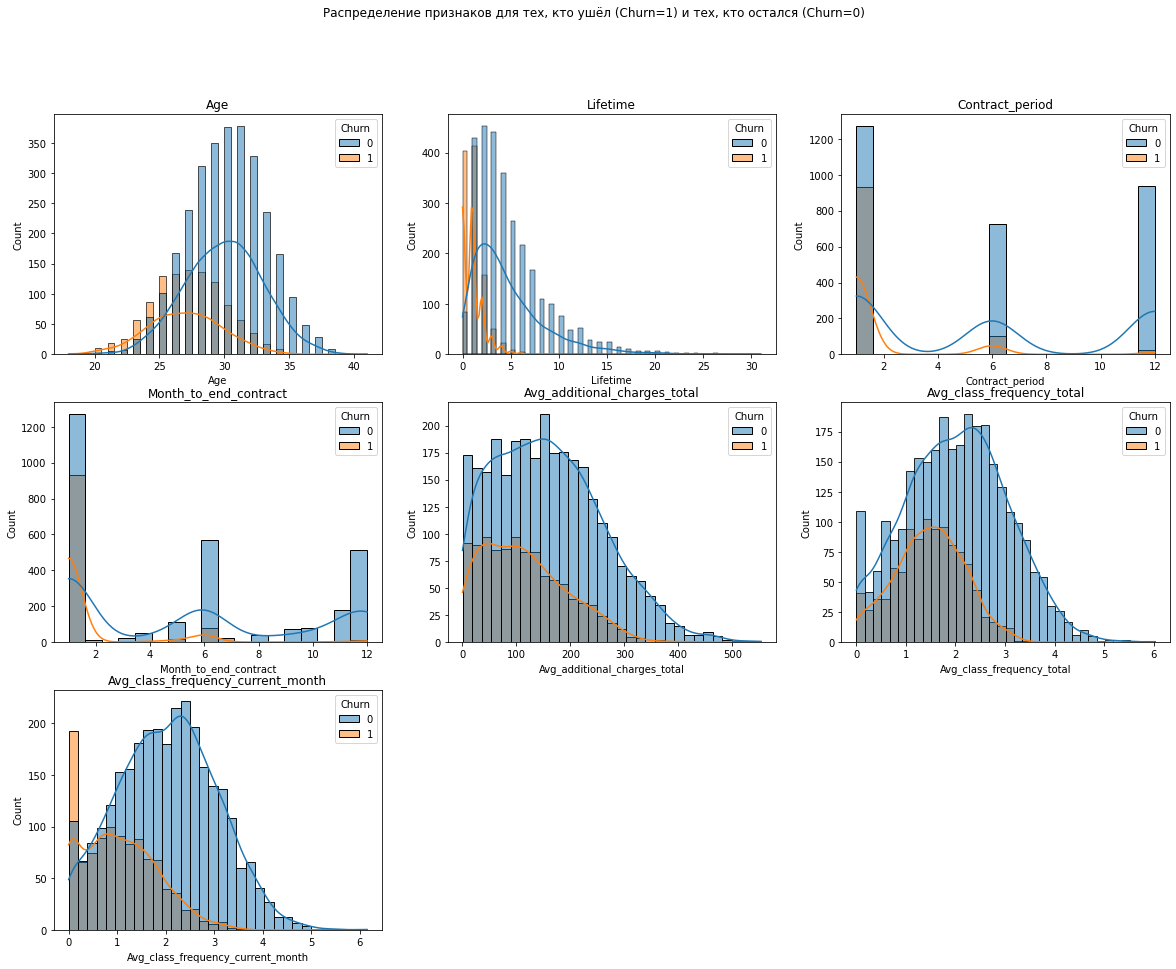

In [5]:
plt.figure(figsize=(20, 15))
for i, column in enumerate(['Age', 
                            'Lifetime',
                            'Contract_period',
                            'Month_to_end_contract',  
                            'Avg_additional_charges_total', 
                            'Avg_class_frequency_total', 
                            'Avg_class_frequency_current_month']):
    plt.subplot(3, 3, i+1)
    sns.histplot(x=column, hue='Churn', data=gym_churn, kde=True)
    plt.title(column)
plt.suptitle('Распределение признаков для тех, кто ушёл (Churn=1) и тех, кто остался (Churn=0)')
plt.show()

Гистограммы распределения были постоены только для количественных признаков. 
1. Распределение клиентов по возрасту близко к нормальному распределению как для ушедших, там и для оставшихся клиентов. 
2. Распределение клиентов по времени прошедшего с момента первого обращения в фитнес-центр имеет форму правостороннего распределения и длинный "хвост". Наличие длинного "хвоста" может обьясняться выбросами, поэтому ниже рассмотрим этот признак отдельно и удалим выбросы.
3. Распредление выручки от дополнительных услуг также иммет форму правостороннего распределения как для ушедших, так и для оставшихся клиентов.
4. Распределение частоты посещения клубов за последний месяц ушедшими клиентами отличается от оставшихся клиентов. Пик для ушедших клиентов приходится на 0, а для оставшихся - 2.5. 
5. Распределение частоты посещения клубов за весь период абонемента  для ушедших и оставшихся клиентов похоже по форме, но имеет пиковое значений в разных точках. Для ушедших клиентов пик находится примерно в 1.5 раза в неделю, а для оставшихся - 2.5 раза в неделю.
6. И ушедшие и оставшиеся клиенты в основном заключают краткосрочные абонементы(на 1 месяц). Но почти все клиенты, имеющие долгосрочные абонементы (6 и 12 месяцев) остаются. Та же тенденция наблюдается и со сроками до окончания абонементы - чем больше срок до окончания абонемента, тем меньше доля ушедших клиентов.

In [ ]:
# 99% процентиль для признака Lifetime
print('99% процентиль для признака Lifetime', gym_churn['Lifetime'].quantile(0.99))

Для сохранения максимального обьема данных, заменим аномально высокие значения данного признака на 17.

In [7]:
# заменяем значения признака Lifetime
gym_churn_up = gym_churn
gym_churn_up.loc[gym_churn_up['Lifetime'] > 17, 'Lifetime'] = 17

### Матрица корреляций

In [8]:
gm = gym_churn_up.corr()
gm

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
gender,1.000000,0.006699,-0.010463,-0.005033,-0.008542,0.000502,0.017879,0.013807,-0.009334,-0.001281,0.015009,0.014620,0.009156,0.000708
Near_Location,0.006699,1.000000,-0.005119,0.210964,-0.015763,0.150233,0.154728,0.058358,0.040761,0.143961,0.072492,0.043127,0.062664,-0.128098
Partner,-0.010463,-0.005119,1.000000,0.451960,0.009970,0.306166,0.022710,0.047480,0.022941,0.294632,0.066690,0.024938,0.045561,-0.157986
Promo_friends,-0.005033,0.210964,0.451960,1.000000,0.001982,0.244552,0.120170,0.050113,0.036898,0.239553,0.077413,0.028063,0.053768,-0.162233
Phone,-0.008542,-0.015763,0.009970,0.001982,1.000000,-0.006893,-0.010099,-0.011403,0.009279,-0.011196,-0.018443,0.008340,0.013375,-0.001177
Contract_period,0.000502,0.150233,0.306166,0.244552,-0.006893,1.000000,0.169991,0.138249,0.111445,0.973064,0.175704,0.096211,0.159407,-0.389984
Group_visits,0.017879,0.154728,0.022710,0.120170,-0.010099,0.169991,1.000000,0.080934,0.032079,0.163703,0.076330,0.056695,0.075923,-0.175325
Age,0.013807,0.058358,0.047480,0.050113,-0.011403,0.138249,0.080934,1.000000,0.080240,0.134511,0.171221,0.119953,0.183095,-0.404735
Avg_additional_charges_total,-0.009334,0.040761,0.022941,0.036898,0.009279,0.111445,0.032079,0.080240,1.000000,0.113958,0.081406,0.044426,0.079570,-0.198697
Month_to_end_contract,-0.001281,0.143961,0.294632,0.239553,-0.011196,0.973064,0.163703,0.134511,0.113958,1.000000,0.166358,0.085387,0.147605,-0.381393


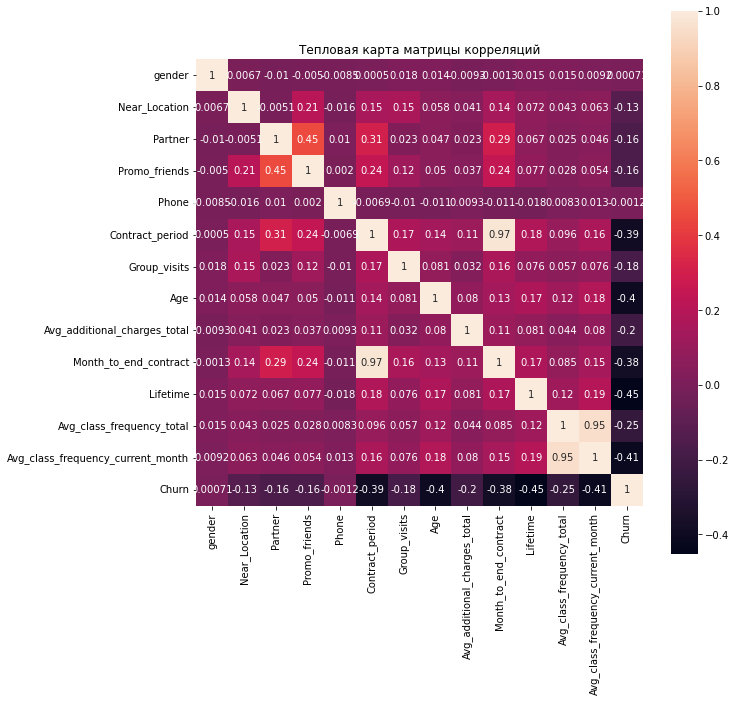

In [9]:
#тепловая карта для матрицы корреляций
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(gm, annot=True, square=True) 
ax.set_ylim(14, 0)
plt.title('Тепловая карта матрицы корреляций')
plt.show()

Наиболее сильно коррелируют с целевой переменной следующие признаки:
1. Время с момента первого обращения клиента. Коэффициент корреляции: -0.45 
2. Среднее количество посещений клуба в неледю за последний месяц. Коэффициент корреляции: -0.41
3. Возраст. Коэффициент корреляции: -0.4

Пол клиента и факт наличия телефона показывает очень слабую  корреляцию с целевой переменной (0.0007 и -0.0012 соответственно). Данные признаки можно исключить из модели, так как они практически никак не влияет на целевую переменную. 

Всего четыре признака имеют сильную попарную корреляцию между собой:
1. Период действия абонемента и срок до окончания абонемента. Коэффициент корреляции: 0.97, что подтверждает сильную корреляцию данных признаков.
2. Среднее количество посещений клуба в неледю за последний месяц и за весь период действия абонемента. Коэффициент корреляции: 0.95. 

Признаки с такой сильной корреляцией между собой нежелательны при использовании линейных моделей. В данном проекте мы будем использовать две модели - логистическую регрессию и "случайный лес". Модель "случайный лес" устойчива к мультиколлинеарности, поэтому для данной модели не критично наличие сильной корреляции между признаками. Логистическая регрессия наоборот чувствительна к мультиколлинеарности, поэтому необходимо оставить только по одному признаку из пар имеющих сильную корреляцию. Из этих пар оставим признаки имеющие более сильную корреляцию с целевой переменной  - это среднее количество посещений клуба в неделю за последний месяц и срок абонемента.  

In [10]:
# удаляем столбцы 
gym_churn_up = gym_churn_up.drop(['gender', 'Phone', 'Avg_class_frequency_total', 'Month_to_end_contract'], axis=1)

Таким образом, удаляем следующие признаки:
1. Гендерный признак клиента (gender)
2. Телефон (Phone)
3. Среднее количество посещений клуба в неделю за весь срок абонемента (Avg_class_frequency_total)
4. Срок до окончания абонемента (Month_to_end_contract)

## Модель прогнозирования оттока клиентов

Строим модель бинарной классификации клиентов, где целевой признак — факт оттока клиента в следующем месяце.

In [11]:
# Разбиваем данные на обучающую и валидационную выборку
X = gym_churn_up.drop(['Churn'], axis=1)
y = gym_churn_up['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

###  Логистическая регрессия

In [12]:
# зададим алгоритм 
lr_model = LogisticRegression(solver='liblinear')
# обучим модель логистической регрессии
lr_model.fit(X_train, y_train)
# воспользуемся уже обученной моделью, чтобы сделать прогноз
lr_predictions = lr_model.predict(X_test)

# выведем все метрики
print('Accuracy: {:.2f}'.format(accuracy_score(y_test, lr_predictions)))
print('Precision: {:.2f}'.format(precision_score(y_test, lr_predictions)))
print('Recall: {:.2f}'.format(recall_score(y_test, lr_predictions)))

Accuracy: 0.90
Precision: 0.79
Recall: 0.79


###  Случайный лес

In [13]:
# зададим алгоритм 
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 0)
# обучим модель случайного леса
rf_model.fit(X_train, y_train)
# воспользуемся уже обученной моделью, чтобы сделать прогноз
rf_predictions = rf_model.predict(X_test)

# выведем все метрики
print('Accuracy: {:.2f}'.format(accuracy_score(y_test, rf_predictions)))
print('Precision: {:.2f}'.format(precision_score(y_test, rf_predictions)))
print('Recall: {:.2f}'.format(recall_score(y_test, rf_predictions)))

Accuracy: 0.89
Precision: 0.79
Recall: 0.75


Доля ушедших клиентов составляет 26,5%, поэтому метрика accuracy может работать не корректно. 
Метрики precision у моделей не отличается. Метрика recall для модели логистической регрессии лучше, чем для модели случайного леса (они ближе к 1). То есть модель логистической регрессии дает меньше ложно отрицательных результатов. При этом количество ложно положительных результатов одиноково для обеих моделей.

In [14]:
# коэффициенты линейной регрессии
coef = pd.DataFrame(gym_churn_up.drop(['Churn'], axis=1).columns, columns = ['name_coef'])
coef['feature_weights']= lr_model.coef_.T
display(coef.sort_values('feature_weights', ascending=False, key=abs))

,name_coef,feature_weights
8,Avg_class_frequency_current_month,-1.097928
7,Lifetime,-0.967942
4,Group_visits,-0.658995
2,Promo_friends,-0.498210
3,Contract_period,-0.265990
5,Age,-0.186189
0,Near_Location,0.046976
1,Partner,-0.019988
6,Avg_additional_charges_total,-0.004886


Метрики логистической регрессии лучше, поэтому проанализируем веса признаков данной модели. 
Наибольшую значимость имеют следующие признаки (в порядке убывания значимости):
1. Среднее количество посещений в неделю за прошедший месяц
2. Период сотрудничества с клубом 
3. Факт посещения групповых зянятий
4. Акция "приведи друга" 
5. Период действия абонемента

## Кластеризация клиентов

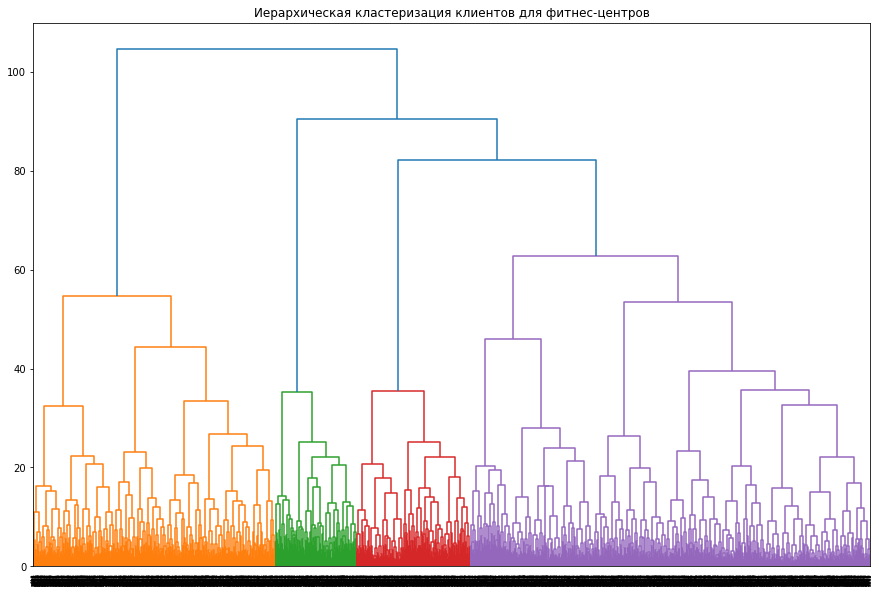

In [15]:
# стандартизируем данные
#X = gym_churn.drop('Churn', axis=1)
sc = StandardScaler()
X = gym_churn.drop('Churn', axis=1)
X_sc = sc.fit_transform(X)

# строим матрицу расстояний функцией linkage() на стандартизованной матрице признаков и дендрограмму
linked = linkage(X_sc, method = 'ward')

plt.figure(figsize=(15, 10))  
dendrogram(linked, orientation='top')
plt.title('Иерархическая кластеризация клиентов для фитнес-центров')
plt.show() 

На основании полученного графика можно выделить 5 групп.

In [16]:
# задаём модель k_means с числом кластеров 5 и фиксируем значение random_state
km = KMeans(n_clusters=5, random_state=0)

# прогнозируем кластеры для наблюдений
labels = km.fit_predict(X_sc)
gym_churn['Class'] = labels

# выводим статистику по средним значениям наших признаков по кластеру
gym_churn.groupby('Class').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
Class,,,,,,,,,,,,,,
0,0.500000,0.944444,0.740385,0.486111,0.900641,11.884615,0.551282,29.933761,164.771986,10.877137,4.625000,2.000652,1.992242,0.022436
1,0.487387,1.000000,0.244144,0.020721,0.899099,1.992793,0.320721,28.219820,130.753745,1.912613,2.366667,1.275604,1.033079,0.527027
2,0.497238,0.000000,0.467772,0.077348,0.915285,2.211786,0.215470,28.480663,133.842859,2.075506,2.755064,1.654082,1.462716,0.451197
3,0.486025,0.998447,0.821429,1.000000,0.899068,3.156832,0.456522,29.228261,141.528068,2.920807,3.686335,1.735768,1.629668,0.246894
4,0.585398,0.970013,0.260756,0.091265,0.908735,2.809648,0.477184,30.126467,162.439280,2.580183,5.112125,2.883373,2.885254,0.066493


Кластеры различаются по средним значениям признаков, в том числе и по оттоку клиентов. 

Кластеры с более лояльными клиентами имеют более длительные сроки абонементов и более длительные сроки сотрудничества с клубом. Эти клиенты в среднем приносят больше выручки по дополнительным услугам и чаще посещают клубы (а также больше клиентов посещает групповые занятия), при этом частота посещения клубов практически не снижается в последнем месяце. Большинство клиентов данных кластеров пользуется акцией "приведи друга" и партнерскими программами. 

Кластеры с менее лояльными клиентами имеют короткие сроки абонементов, приносят меньше выручки по дополнительным услугам и реже посещаю клубы, при этом частота посещений заметно снижается в последний месяц. Данные клиенты меньше пользуются акцией "приведи друга" и партнерскими программами. 

In [17]:
# посчитаем метрику силуэта для нашей кластеризации
print('Silhouette_score: {:.2f}'.format(silhouette_score(X_sc, labels)))

Silhouette_score: 0.13


Метрика силуэта находится близко в 0. Это значит, что есть перекрывающиеся кластеры (то есть клиенты могут находится примерно на одном расстоянии от двух или больше кластеров). 

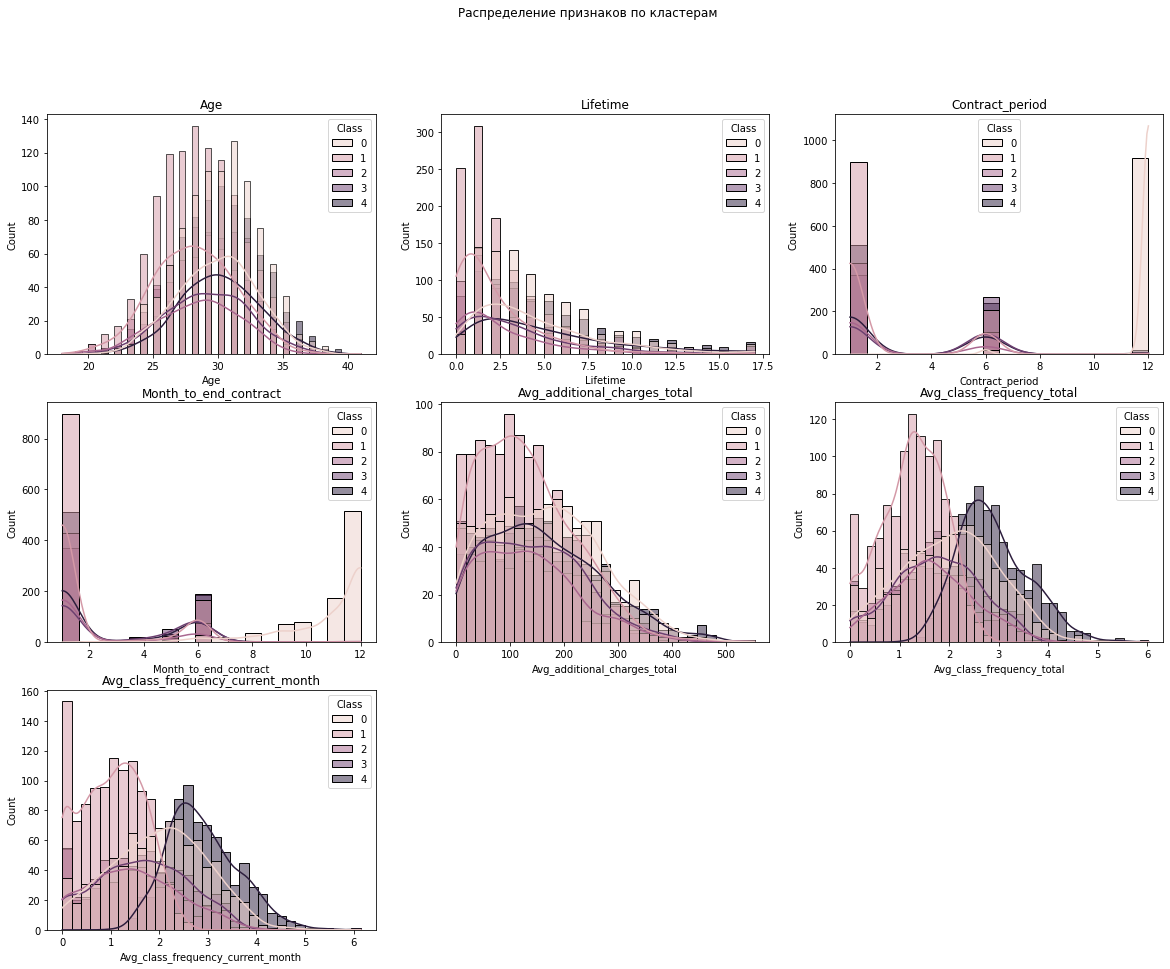

In [18]:
# распределение признаков для кластеров
plt.figure(figsize=(20, 15))
for i, column in enumerate(['Age', 
                            'Lifetime',
                            'Contract_period',
                            'Month_to_end_contract',  
                            'Avg_additional_charges_total', 
                            'Avg_class_frequency_total', 
                            'Avg_class_frequency_current_month']):
    plt.subplot(3, 3, i+1)
    sns.histplot(x=column, hue='Class', kde=True, data=gym_churn)
    plt.title(column)
plt.suptitle('Распределение признаков по кластерам')
plt.show()

Графики распределения признаков подтверждают различия кластеров по признакам. Но явно выраженные разлчия есть не по всем признакам. Например, распределение клиентов по возрасту и выручке от дополнительных услуг похоже для всех групп.

In [19]:
# доля оттока клиентов по кластерам 
display(gym_churn.groupby('Class')['Churn'].mean().sort_values(ascending=False))

Class
1    0.527027
2    0.451197
3    0.246894
4    0.066493
0    0.022436
Name: Churn, dtype: float64

Наибольшую склонность к оттоку имеет кластер номер 1 (доля ушедших клиентов - 53%) и кластер 2 (45%), наиболее лояльны клиенты 0 кластера (доля ушедших клиентов - 2.2%) и кластер 4 (6.6%). 

## Вывод

Для снижения оттока клиентов необходимо усилить привлечение более лояльных клиентов. В данном случае это клиенты пришедшие по акции "приведи друга", клиенты-сотрудники компаний-партнеров клуба, клиенты часто посещающие клуб (в том числе групповые занятия), имеющие длительные абонементы и сотрудничающие с клубом длительный период.  

Для привлечения лояльных клиентов необходимо:
1. Развивать партнерские программы (привлекать к сотрудничеству новые компании).
2. Проанализаровать и расширить действие акции "приведи друга" (рассмотреть возможность дополнительной мотивировации клиентов клуба для привлечения их друзей).
3. Проанализировать соотношение цен долгосрочных и краткосрочных абонементов для выявления возможности увеличения ценовой привлекателности долгосрочных абонементов. 
4. Стимулировать клиентов чаще посещать клуб (в том числе групповые знаятия). Необходим анализ популярности групповых занятия клуба среди клиентов и анализ групповых занятия конкурентов (для расширения видов проводимых в клубе групповых занятий).